In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import numpy as np
import json
import os

from scripts.TrimerAnalyze import medians_info
from scripts.TAhelpers import find_region, assign_region, split_rows, label_2cols

----
# Importing raw datasets form MySQL server

In [2]:
run_TrimerSQL = False

if run_TrimerSQL:
    import scripts.TrimerSQL as sql
    
    # Setting up database connection via json config file
    with open("sql.json") as file:
        sql_info = json.load(file)
    
    username, password, ip, port, database = list(sql_info.values())

    # SQL conneccot, the info_list need to contain the host ip, port, username, password and wasted database
    info_list = [ip, port, username, password, database]

    sql_conn = sql.mysql(input_host = info_list[0],
                         input_port = info_list[1],
                         input_username = info_list[2],
                         input_password = info_list[3],
                         input_database = info_list[4])
    
    sql_conn.import_tables()

---
# Creating trimers-lpa input file

In [3]:
run_TrimerCreate = False

if run_TrimerCreate:
    import scripts.TrimerCreate as trimer
    
    source_options = ["germline", "top_seq", "all_seq", "representative"][-2]
    trim_obj = trimer.Trimer(seqs_loc="trimers_raw_tables\\covid_vaccine_new.sequences.csv",
                             seq_collapsed_loc="trimers_raw_tables\\covid_vaccine_new.sequence_collapse.csv", 
                             metadata_loc="trimers_raw_tables\\covid_vaccine_new.sample_metadata.csv",
                             clones_loc = "trimers_raw_tables\\covid_vaccine_new.clones.csv",
                             clones_stats_loc = "trimers_raw_tables\\covid_vaccine_new.clone_stats.csv",
                             metadata_list=["cell_subset", "collection_time_point_relative"],
                             source = source_options,
                             rename_metadata=True,
                             new_metadata_names=["ab_target", "time_point"]
                             )
    
    triemrs = trim_obj.create(subdatasets_list=["ab_target","time_point","subject_id"],  save_csv=True)

In [4]:
trimers_rep_file = os.path.join("trimers_data", "ab_target-time_point-subject_id-representative-trimers_[14.05.26-23;31].csv")

---
# Performing: LPA analysis on the trimers input & reducing the dimensionality via PCA

In [5]:
run_TrimerLPA = True
if run_TrimerLPA:
    import scripts.TrimerLPA as trLPA

    trimer_lpa = trLPA.TrimerLPA(input_data=trimers_rep_file, min_treshold=100) #creating trimer LPA object
    pca, var = trimer_lpa.pca() # performing PCA analysis

> The following document havn't met the treshold (100):
                  document  frequency_in_document
19  Spike+MemB.1baseline.7                      8
24     Spike+MemB.2weeks.7                     48
26     Spike+MemB.4weeks.4                     83


---
# Visulizing the reducted PCA-LPA data via scatterplot

AB Target 0
Time Point 1
Subject 2


C:\Users\Daniel\AppData\Local\Temp\ipykernel_21544\2123787584.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1, 1))


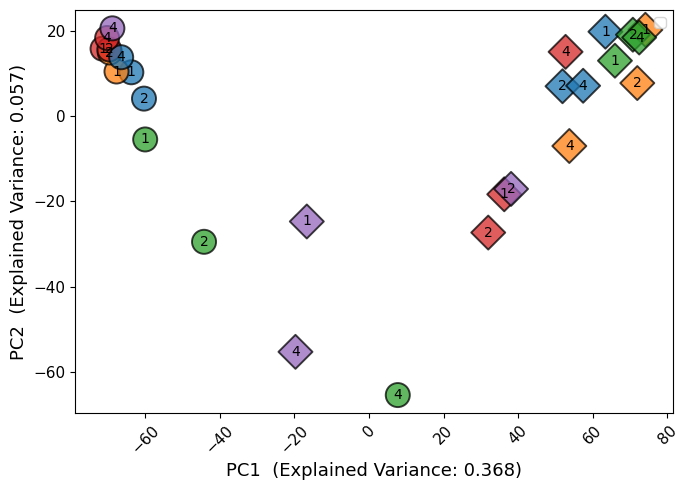

In [6]:
vis_pca = True

if vis_pca:

    pca_copy = pca.copy()
    values_dict = {"AB Target":[0, {"Spike+MemB":"SP", "Non-SpikeB":"SN"}], 
                   "Time Point":[1, {"1baseline":"1", "2weeks":"2", "4weeks":"4"}], 
                   "Subject":[2, {i:j for i,j in zip(["3","4","5","6","7"], [f"subj_{j}" for j in [3,4,5,6,7]])}]}

    for i in values_dict:
        print(i, values_dict[i][0])
        pca_copy[i]= pca_copy.index.str.split(".").to_series().apply(lambda X : X[values_dict[i][0]]).values
        pca_copy[i] = pca_copy[i].map(values_dict[i][1])

    var_list = [round(i,3) for i in var.Variance.values]


    # Plotting scatterplot of the PC results
    var_list = [round(i,3) for i in var.Variance.values]
    PCx, PCy = 1, 2

    # unique ab_target types
    markers_map = {"SP": "o", "SN": "D"}

    fig, ax1 = plt.subplots(1,1, figsize=(7,5))
    sns.scatterplot(data = pca_copy, 
                    x=f"PC{PCx}", 
                    y=f"PC{PCy}", 
                    hue="Subject", 
                    style="AB Target",
                    markers=markers_map, 
                    ax=ax1,
                    s=300,
                    alpha=0.75,
                    edgecolor="black",
                    legend=False)

    ax1.tick_params(axis="both", labelsize=11)
    ax1.tick_params(axis="x", rotation=45)
    ax1.set_xlabel(f"PC{PCx} " + f" (Explained Variance: {str(var_list[PCx - 1])})", fontsize=13)
    ax1.set_ylabel(f"PC{PCy} " + f" (Explained Variance: {str(var_list[PCy - 1])})", fontsize=13)

    metadata = "Time Point"
    text_df = pca_copy[[f"PC{PCx}", f"PC{PCy}", metadata]]

    for i in text_df.iterrows():
        i_slice = i[1]
        i_x, i_y, i_label = i_slice.values

        ax1.text(x=i_x, 
                y=i_y, 
                s=i_label,
                ha='center', 
                va='center')
        
    plt.legend(bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show()

---
# Analyzing the LPA results based on the substitution survival extreme positions

In [7]:
# positions from previus analysis [28,104]
pa_positions = [ 28,  29,  30,  31,  34,  35,  36,  37,  38,  39,  40,  41,  42,
                 44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,
                 57,  58,  59,  62,  63,  64,  65,  66,  67,  68,  69,  70,  71,
                 72,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,
                 86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  
                 99,  100, 101, 102, 103, 104
                 ]

pa_head = [104,  98,  38,  41,  86,  83,  75,  81,  44,  102,  89,  94,  51,  50,  48,  46,  79,  37] # most 18 extreame POSITIVE positions
pa_tail = [64,  59,  58,  92,  66,  101,  90,  35,  85,  87,  62,  65,  95,  57,  74,  68,  34,  55] # most 18 extreame NEGATIVE positions
 
pa_joined = pa_head +  pa_tail

In [8]:
to_save = False
to_save_mds = False
from scripts import TrimerAnalyze 

trimer_init = TrimerAnalyze.TrimerAnalysis(trimer_input=trimers_rep_file) #inititating the class
trimer_divr = trimer_init.diversity_analysis(save_csv=to_save, div_orders= [0, 1, 2, 3]) #creating position analysis
trimer_count = trimer_init.trimer_presence(save_csv=to_save, index_labels = {0:"ab_target", 1:"time_point", 2:"subject_id"}, diversity=[1,2]) #creating trimers analysis

In [9]:
# importing the raw trimers and selecting only cdr/fw rows
raw_trimers = pd.read_csv(trimers_rep_file, index_col=0)
raw_trimers = raw_trimers[raw_trimers.region.isin(['cdr1', 'fw2', 'cdr2', 'fw3'])]

medians = medians_info(raw_trimers = raw_trimers,
                      lpa_sig = trimer_lpa.sig_df,
                      index_unique = {0:["Non-SpikeB", "Spike+MemB"]},
                      index_name="ab_target")

medians_filt = medians.filter_sort(on="Spike+MemB_median",
                                   sort_ascending=False,
                                   filter_how="qnt",
                                   save_csv=to_save_mds)

> 3200 unique trimers in divresity of order 1. Producing histogram.


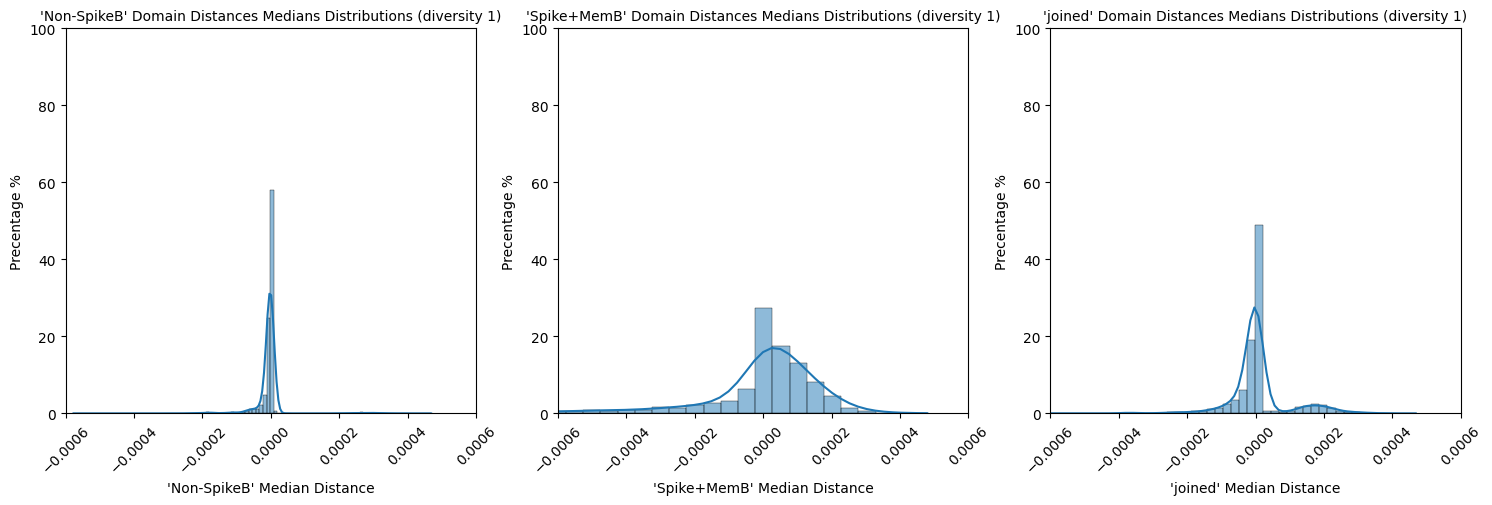

In [10]:
medians.plot_median_hist(trimer_pres=trimer_count,
                         div=1,
                         xy_limit=(-0.0006, 0.0006, 0, 100), 
                         save_fig=to_save_mds)

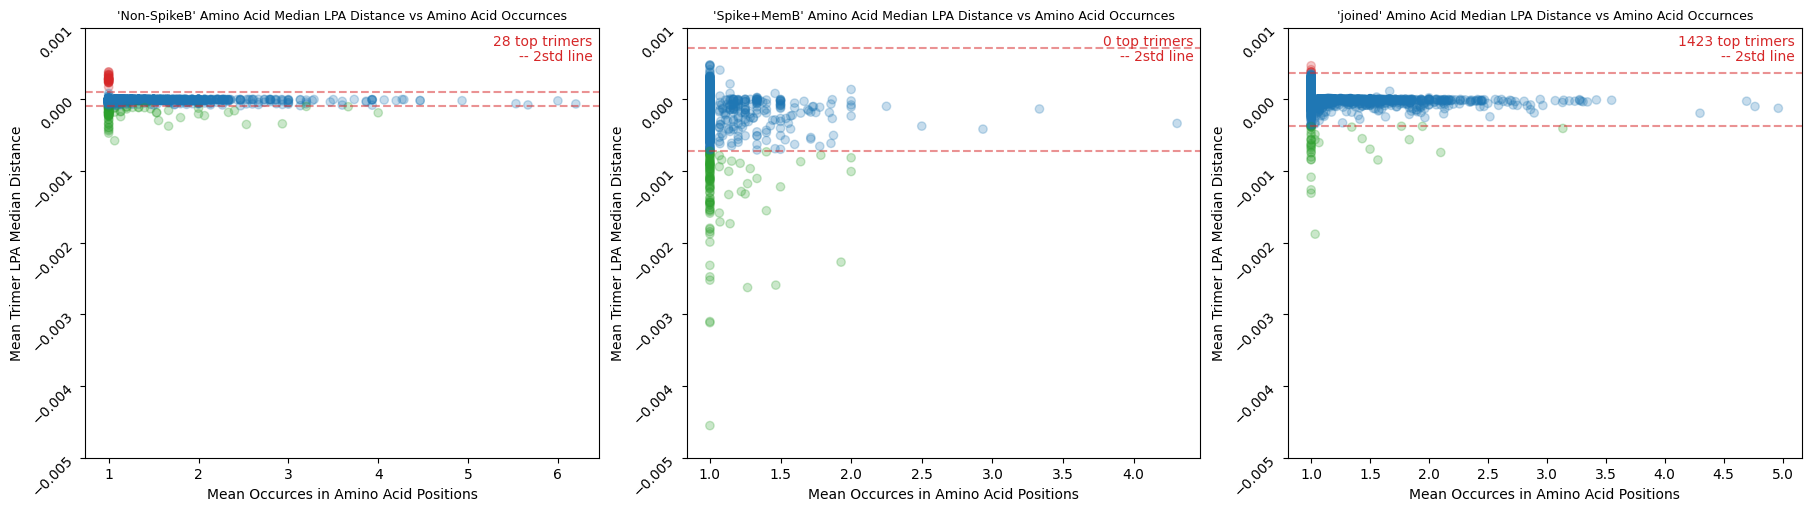

> Non-precense trimers were dropped from the figure, the top trimers count != 25% of the trimers 
> Non-precense trimers still have median distance due to the scoring method.


In [11]:
top_trimers = medians.plot_median_presence(trimer_pres=trimer_count, 
                                           div_pres=1,
                                           stat="2std",
                                           return_data=True,
                                           save_fig=to_save_mds)

---
# Extreme positive and negative position analysis

In [12]:
# Heatmap that presents the 
def heatmap_trimers(trimers_input : pd.DataFrame,
                    remove_v1 : bool = False,
                    remove_v0 : bool = True,
                    fig_height : int = 10,
                    div : int = 1,
                    show_fig : bool = True):
    """
    Takes a trimers informative dataframe and visualizing trimers occurnces across different subjects
    as heatmap plot.

    trimers_input : pd.DataFrame -> takes dataframe of trimers with columns of '['subject_id', 'trimer', 'div1_unqpos', 'div1_ncount']'.
    remove_v1 : bool -> replace cells with values smaller than 1 with zeros.
    remove_v0 : bool -> removes rows with the sum of 0.
    fig_height : int -> height of the plot.
    div : int -> order of diversity in analysis.
    show_fig : bool -> show the pyplot figure output.
    """
    
    heatmap_trimers = pd.DataFrame(index = trimers_input.trimer.unique(),
                                   columns= [str(i) for i in range(28,105)],
                                   data=0)

    for sid in trimers_input.subject_id.unique():
        temp_df = trimers_input[trimers_input.subject_id == sid]

        for i in temp_df.iterrows():
            i_trimer, i_pos, i_count = i[1]["trimer"], str(i[1][f"div{div}_unqpos"]), int(i[1][f"div{div}_ncount"])

            if i_trimer in temp_df.trimer.values: 
                heatmap_trimers.loc[i_trimer, i_pos] += 1

    # Removing <1 points
    if remove_v1:
        mask_bool = (heatmap_trimers != 1) 
        heatmap_trimers = heatmap_trimers[mask_bool].fillna(0).astype("int")


    # Removing rows with sum of 0 from plot
    if remove_v0:
        nonzero_rows = (heatmap_trimers.sum(axis=1) != 0)
        heatmap_trimers = heatmap_trimers[nonzero_rows.values]

    heatmap_array, heatmap_cols, heatmap_index = heatmap_trimers.to_numpy(), heatmap_trimers.columns, heatmap_trimers.index

    fig, ax = plt.subplots(1,1, figsize=(16,fig_height))
    sns.heatmap(heatmap_array, ax=ax, cbar_kws={'label': 'Occurrences in Unique Subjects'})
    ax.set_xticks(labels=heatmap_cols, ticks=range(0,77))
    ax.set_xticklabels(labels=heatmap_cols, rotation=90)
    ax.set_yticks(labels=heatmap_index, ticks=range(0,len(heatmap_index)), rotation=0)


    ax.set_xlabel("Unique Trimer")
    ax.set_ylabel("Amino Acid Position")

    range_cdr = list(range(27,39)) + list(range(56,66)) #CDR1, CDR2
    for xtick, xcolor in zip(ax.get_xticklabels(), ["tab:red" if i in range_cdr else "black" for i in heatmap_cols.astype("int")]):
        xtick.set_color(xcolor)

    if show_fig == False:
        plt.close()

    return heatmap_trimers

In [13]:
# diversity of the analysis
div = 1 #diversity order
trimer_count_copy = trimer_count.copy().fillna(0)

# Data of the high medians trimers
filt_high1 = top_trimers['Spike+MemB'].index
filt_high2 = medians_filt[medians_filt["Spike+MemB_median_qnt"] == 1].trimer.unique() #relevent trimers (top median)
relv_high = trimer_count_copy[(trimer_count_copy.trimer.isin(filt_high2)) & (trimer_count_copy[f"div{div}_npos"] != 0)]

# Data of the low median trimers.
filt_low = medians_filt[medians_filt["Spike+MemB_median_qnt"] == 0.25].trimer.unique() #relevent trimers (bottom median)
relv_low = trimer_count_copy[(trimer_count_copy.trimer.isin(filt_low)) & (trimer_count_copy[f"div{div}_npos"] != 0) & (trimer_count_copy[f"div{div}_npos"].notnull())]

# Dataframe of the analysis
pipeline_df = relv_high

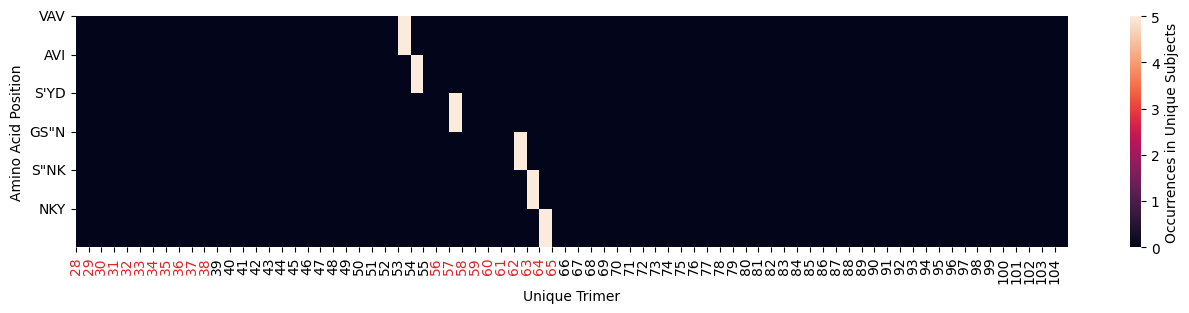

In [16]:
ab_targets = ["Spike+MemB", "Non-SpikeB"]

div = 1
rtimer_count_cp = trimer_count.fillna(0)
rtimer_count_cp = split_rows(rtimer_count_cp[(rtimer_count_cp[f"div1_npos"] != 0) & 
                                             (rtimer_count_cp.trimer.isin(filt_high2)) & 
                                             (rtimer_count_cp.ab_target==ab_targets[0])], div=1)

cp_grouped = rtimer_count_cp.groupby(["subject_id","trimer", f"div{div}_unqpos"]).agg({f"div{div}_ncount":"sum"}).reset_index()
cp_grouped["div1_unqpos"] = cp_grouped["div1_unqpos"].astype("int")
cp_grouped.sort_values("div1_unqpos", inplace=True)

heatmap_sp_sp = heatmap_trimers(cp_grouped,remove_v0=True, remove_v1=True, fig_height=3, show_fig=True)

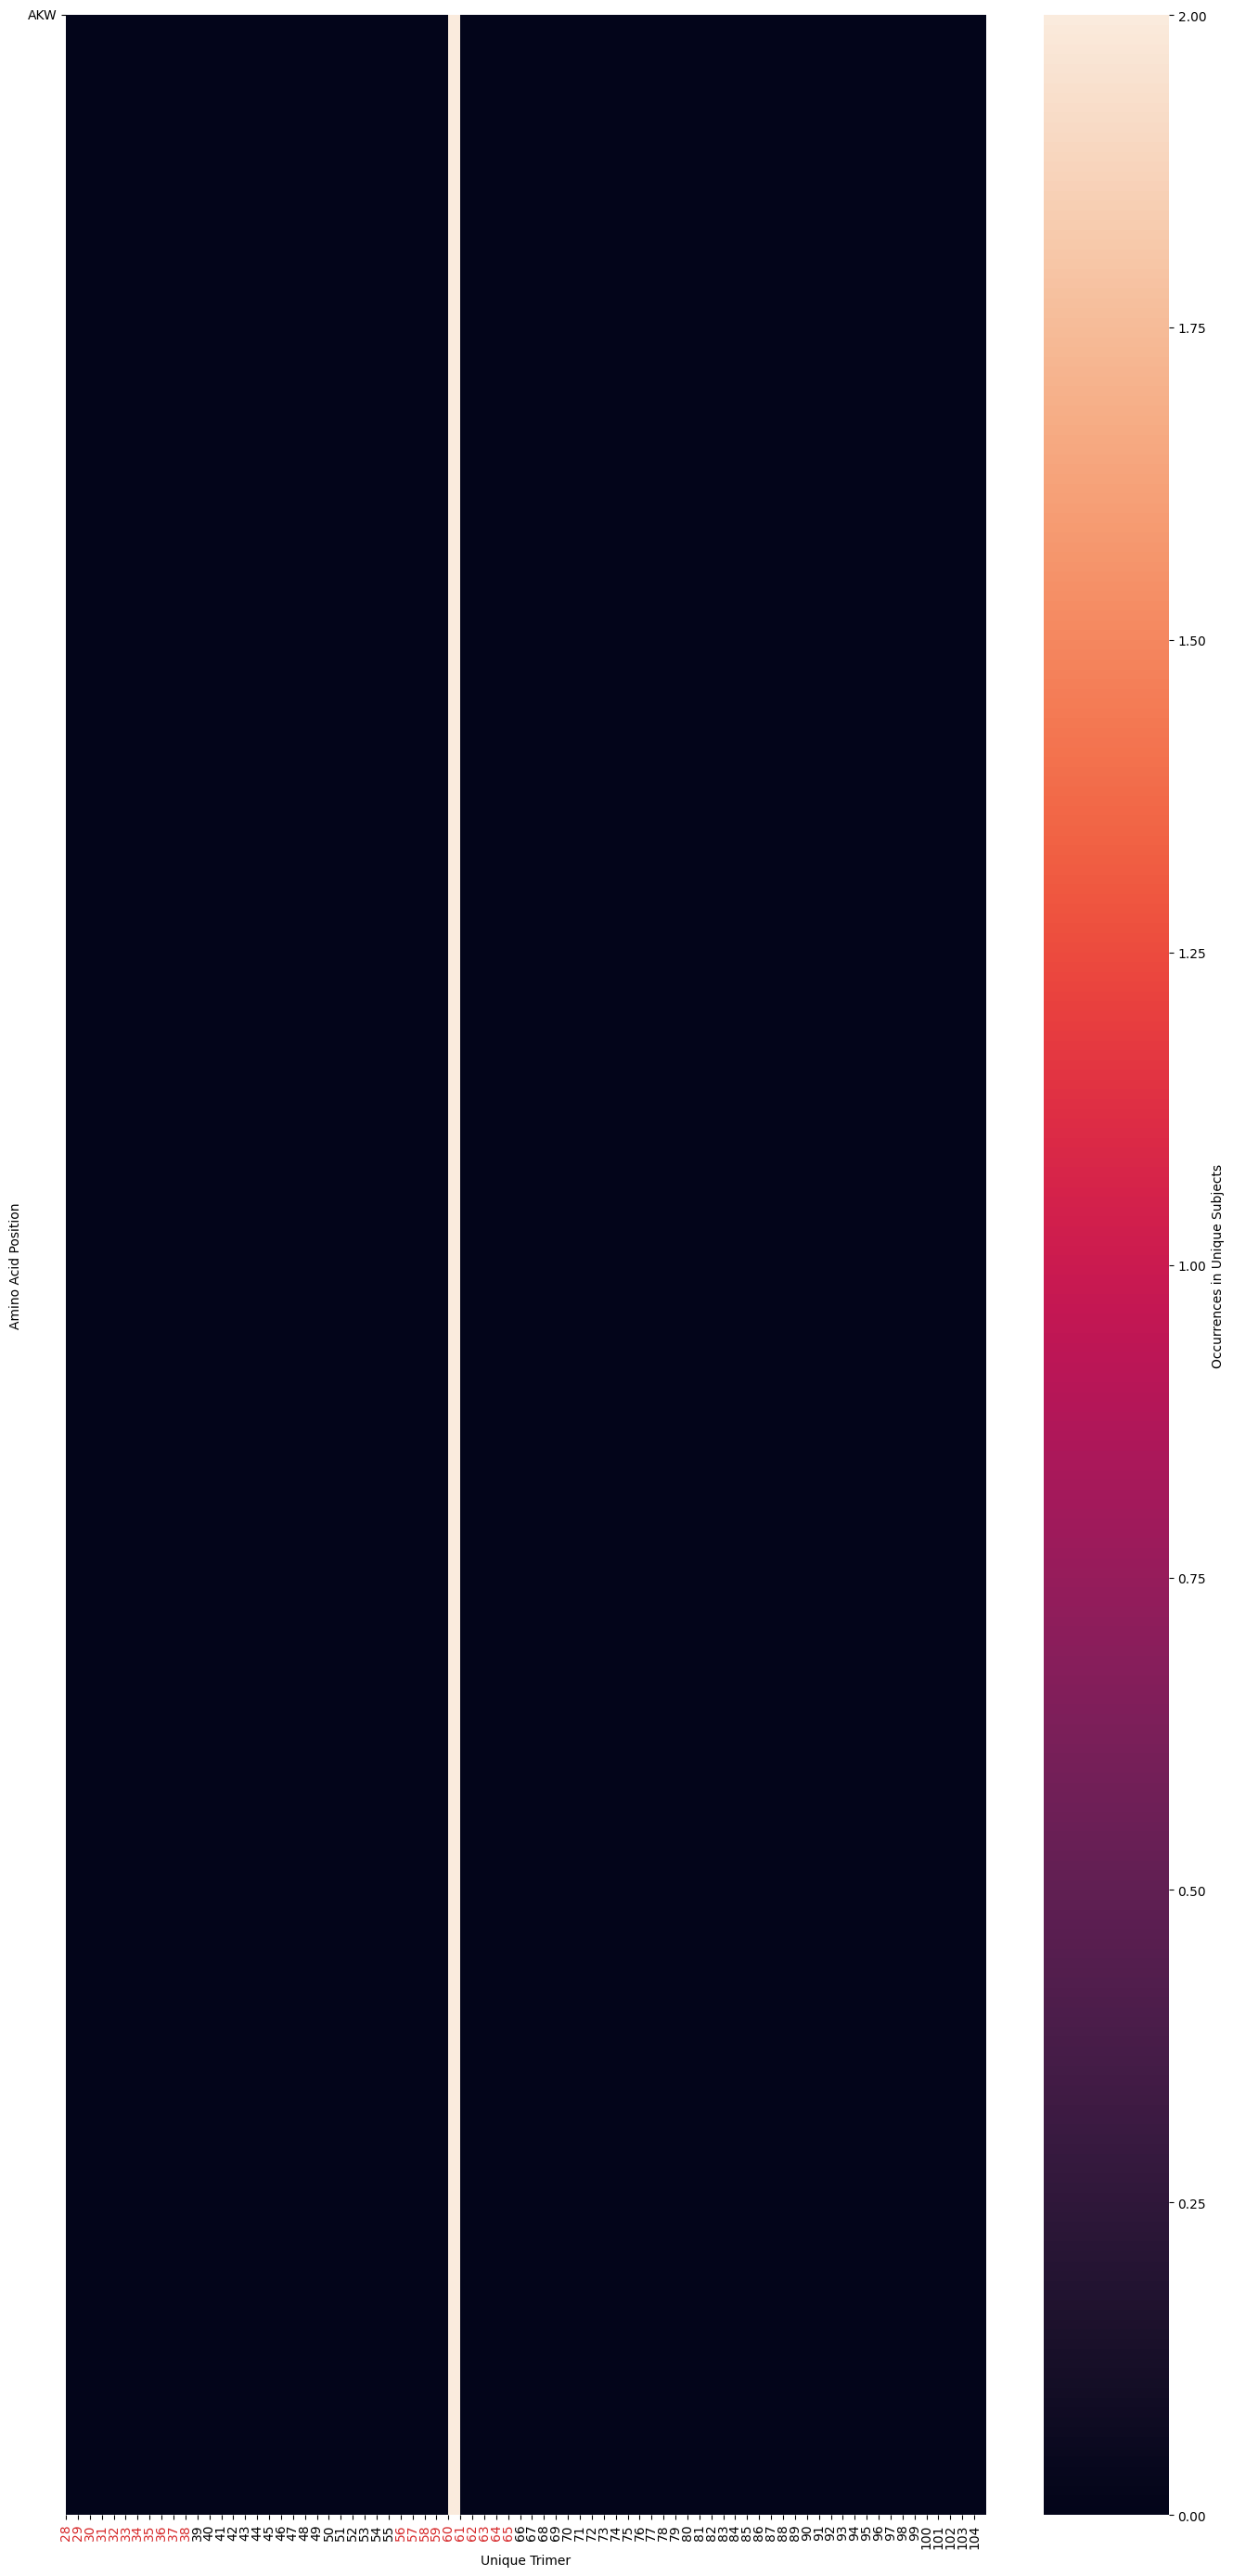

In [21]:
# Sorting the medians_filt dataframe by the SN median values
medians_filt_SN = medians.filter_sort(on="Non-SpikeB_median",
                                      sort_ascending=False,
                                      filter_how="qnt",
                                      save_csv=False)

# Getting a list of the top precentile trimers (unique)
filt_high3 = medians_filt_SN[medians_filt_SN["Non-SpikeB_median_qnt"] == 1].trimer.unique() #relevent trimers (top median - by SN)

# List of ab_target types
ab_targets = ["Spike+MemB", "Non-SpikeB"]

# Getting relevent SN top trimers values
div = 1
rtimer_count_SN = trimer_count.fillna(0)
rtimer_count_SN = split_rows(rtimer_count_SN[(rtimer_count_SN[f"div1_npos"] != 0) & 
                                             (rtimer_count_SN.trimer.isin(filt_high3)) & 
                                             (rtimer_count_SN.ab_target==ab_targets[1])], div=1)
SN_grouped = rtimer_count_SN.groupby(["subject_id","trimer", f"div{div}_unqpos"]).agg({f"div{div}_ncount":"sum"}).reset_index()
SN_grouped["div1_unqpos"] = SN_grouped["div1_unqpos"].astype("int")
SN_grouped.sort_values("div1_unqpos", inplace=True)

heatmap_sn_sp = heatmap_trimers(SN_grouped, remove_v0=True, remove_v1=True, fig_height=35)

In [4]:
import pandas as pd
import os
test = pd.read_csv(os.path.join("trimers_processed_tables", "cleaned_seqs_all_seq.csv"), index_col=0)

In [8]:
(test.sequence.apply(len) == test.germline.apply(len)).value_counts()

True    169266
Name: count, dtype: int64